# 🗑️ Smart Bin — Combined Dataset Trainer

Merges **two Kaggle garbage datasets** into **5 unified classes** and trains a MobileNetV2 model.

| Bin | Class | Sources |
|-----|-------|---------|
| 🟦 | **glass** | glass, green-glass, brown-glass, white-glass (DS1) + glass (DS2) |
| 🟥 | **metal** | metal (both) |
| 🟫 | **paper** | paper, cardboard (both) |
| 🟩 | **plastic** | plastic (both) |
| ⬛ | **rejected_waste** | biological, clothes, shoes, battery, trash (DS1) + trash (DS2) |

**Datasets:**
- Dataset 1: `hassnainzaidi/garbage-classification` (12 categories, pre-split)
- Dataset 2: `zlatan599/garbage-dataset-classification` (6 categories, ~2000/class)

> Run each cell in order. Training takes ~5–10 min on a Colab GPU.

## Step 1 — Install Dependencies

In [13]:
!pip install -q kagglehub tensorflow matplotlib

## Step 2 — Imports & Configuration

In [12]:
import os
import shutil
import random
from collections import defaultdict

import kagglehub
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# ─── Configuration ───────────────────────────────────────────────────────
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 32
EPOCHS         = 10
RANDOM_SEED    = 42

OUTPUT_ROOT    = './combined_dataset'
EXPORT_DIR     = './exported_models'
MODEL_NAME     = 'smart_bin_model'

# Dataset 2 split ratios (Dataset 1 already has train/val/test)
DS2_TRAIN_RATIO = 0.70
DS2_VAL_RATIO   = 0.15
DS2_TEST_RATIO  = 0.15

TARGET_CLASSES = ['glass', 'metal', 'paper', 'plastic', 'rejected_waste']
SPLITS         = ['train', 'val', 'test']
IMAGE_EXTS     = ('.jpg', '.jpeg', '.png', '.webp', '.bmp', '.gif')

print('\u2705 Configuration loaded.')
print(f'  Output dataset : {OUTPUT_ROOT}')
print(f'  Export dir      : {EXPORT_DIR}')
print(f'  Target classes  : {TARGET_CLASSES}')

✅ Configuration loaded.
  Output dataset : ./combined_dataset
  Export dir      : ./exported_models
  Target classes  : ['glass', 'metal', 'paper', 'plastic', 'rejected_waste']


## Step 3 — Define 5-Class Bin Mappings

Maps original category folder names from both datasets to the 5 unified classes.
Includes case variations to handle different folder naming conventions.

In [3]:
# Dataset 1: hassnainzaidi/garbage-classification
# Handles both plain 'glass' folder AND color-specific subfolders
DS1_BIN_MAP = {
    # Glass (plain folder or color-specific)
    'glass':        'glass',
    'Glass':        'glass',
    'green-glass':  'glass',
    'brown-glass':  'glass',
    'white-glass':  'glass',
    # Metal
    'metal':        'metal',
    'Metal':        'metal',
    # Paper
    'paper':        'paper',
    'Paper':        'paper',
    'cardboard':    'paper',
    'Cardboard':    'paper',
    # Plastic
    'plastic':      'plastic',
    'Plastic':      'plastic',
    # Rejected waste
    'biological':   'rejected_waste',
    'Biological':   'rejected_waste',
    'clothes':      'rejected_waste',
    'clothing':     'rejected_waste',
    'shoes':        'rejected_waste',
    'battery':      'rejected_waste',
    'batteries':    'rejected_waste',
    'trash':        'rejected_waste',
    'Trash':        'rejected_waste',
}

# Dataset 2: zlatan599/garbage-dataset-classification
DS2_BIN_MAP = {
    'glass':        'glass',
    'Glass':        'glass',
    'metal':        'metal',
    'Metal':        'metal',
    'paper':        'paper',
    'Paper':        'paper',
    'cardboard':    'paper',
    'Cardboard':    'paper',
    'plastic':      'plastic',
    'Plastic':      'plastic',
    'trash':        'rejected_waste',
    'Trash':        'rejected_waste',
}

BIN_LABELS = {
    'glass':          '\U0001f7e6 Glass',
    'metal':          '\U0001f7e5 Metal',
    'paper':          '\U0001f7eb Paper',
    'plastic':        '\U0001f7e9 Plastic',
    'rejected_waste': '\u2b1b Rejected Waste',
}

print('\u2705 Bin mappings defined.')
print(f'  DS1 categories mapped: {len(DS1_BIN_MAP)}')
print(f'  DS2 categories mapped: {len(DS2_BIN_MAP)}')

✅ Bin mappings defined.
  DS1 categories mapped: 22
  DS2 categories mapped: 12


## Step 4 — Download Both Datasets

In [4]:
print('\U0001f4e5 Downloading Dataset 1: hassnainzaidi/garbage-classification ...')
ds1_path = kagglehub.dataset_download('hassnainzaidi/garbage-classification')
print(f'   \u2705 Dataset 1 path: {ds1_path}')

print('\n\U0001f4e5 Downloading Dataset 2: zlatan599/garbage-dataset-classification ...')
ds2_path = kagglehub.dataset_download('zlatan599/garbage-dataset-classification')
print(f'   \u2705 Dataset 2 path: {ds2_path}')

📥 Downloading Dataset 1: hassnainzaidi/garbage-classification ...


100%|██████████| 123M/123M [00:00<00:00, 182MB/s]

Extracting files...


   ✅ Dataset 1 path: /root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1

📥 Downloading Dataset 2: zlatan599/garbage-dataset-classification ...


100%|██████████| 121M/121M [00:00<00:00, 149MB/s]

Extracting files...


   ✅ Dataset 2 path: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5


## Step 5 — Detect Dataset Structures

Automatically detects the folder structure of both datasets.
- Dataset 1 has `train/val/test` splits
- Dataset 2 may have categories nested inside an `images/` subfolder — the script handles this

In [5]:
# --- Dataset 1: detect root folder ---
ds1_root = ds1_path
for candidate in ['garbage_classification', 'Garbage classification', 'Garbage_classification']:
    test_path = os.path.join(ds1_path, candidate)
    if os.path.isdir(test_path):
        ds1_root = test_path
        break

print(f'\U0001f4c2 Dataset 1 root: {ds1_root}')
for split in SPLITS:
    sp = os.path.join(ds1_root, split)
    if os.path.isdir(sp):
        cats = sorted(os.listdir(sp))
        print(f'   {split}/  \u2192  {cats}')
    else:
        print(f'   \u26a0\ufe0f  {split}/ not found')

# --- Dataset 2: smart root detection ---
# Walks down directory tree to find the folder containing actual category dirs
def find_category_root(path, bin_map, max_depth=3):
    """Recursively find the folder that contains category subdirectories."""
    if max_depth == 0:
        return path
    try:
        subdirs = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
    except OSError:
        return path
    if not subdirs:
        return path

    # Check if current subdirs match known category names from our bin_map
    mapped = [d for d in subdirs if d in bin_map]
    if len(mapped) >= 2:  # At least 2 recognized categories = this is the root
        return path

    # Check if this has train/val/test structure
    if all(s in subdirs for s in ['train', 'val', 'test']):
        return path

    # Otherwise, recurse into subdirectories (e.g., 'images/' or wrapper dirs)
    for d in subdirs:
        child = os.path.join(path, d)
        result = find_category_root(child, bin_map, max_depth - 1)
        if result != child:  # Found categories deeper
            return result
        # Also check this child directly
        try:
            child_subdirs = [sd for sd in os.listdir(child) if os.path.isdir(os.path.join(child, sd))]
        except OSError:
            continue
        child_mapped = [sd for sd in child_subdirs if sd in bin_map]
        if len(child_mapped) >= 2:
            return child

    return path

ds2_root = find_category_root(ds2_path, DS2_BIN_MAP)
print(f'\n\U0001f4c2 Dataset 2 root: {ds2_root}')

# Check if DS2 has train/val/test splits
has_train_folder = os.path.isdir(os.path.join(ds2_root, 'train'))
if has_train_folder:
    train_contents = os.listdir(os.path.join(ds2_root, 'train'))
    ds2_has_splits = any(os.path.isdir(os.path.join(ds2_root, 'train', c)) for c in train_contents)
else:
    ds2_has_splits = False

if ds2_has_splits:
    print('   Structure: Has train/val/test splits')
    for split in SPLITS:
        sp = os.path.join(ds2_root, split)
        if os.path.isdir(sp):
            cats = sorted([c for c in os.listdir(sp) if os.path.isdir(os.path.join(sp, c))])
            print(f'   {split}/  \u2192  {cats}')
else:
    print('   Structure: Flat (no splits \u2014 will auto-split 70/15/15)')
    cats = sorted([c for c in os.listdir(ds2_root) if os.path.isdir(os.path.join(ds2_root, c))])
    print(f'   Categories: {cats}')

📂 Dataset 1 root: /root/.cache/kagglehub/datasets/hassnainzaidi/garbage-classification/versions/1/Garbage classification
   train/  →  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   val/  →  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
   test/  →  ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

📂 Dataset 2 root: /root/.cache/kagglehub/datasets/zlatan599/garbage-dataset-classification/versions/5/Garbage_Dataset_Classification/images
   Structure: Flat (no splits — will auto-split 70/15/15)
   Categories: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Step 6 — Merge & Copy into Combined Dataset

Copies all images from both datasets into `combined_dataset/` with the 5-class folder structure.
- Dataset 1’s existing splits are preserved
- Dataset 2 is auto-split 70/15/15 if it has no splits
- Filenames are prefixed to avoid collisions

In [6]:
stats = defaultdict(lambda: defaultdict(int))
skipped = []

# Create output folders
for split in SPLITS:
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(OUTPUT_ROOT, split, cls), exist_ok=True)


def copy_images(src_dir, dst_dir, prefix, category, bin_map, stats_dict, split_name):
    """Copy images from a source category folder to the target bin folder."""
    bin_name = bin_map.get(category)
    if bin_name is None:
        skipped.append(f'{prefix}/{category}')
        print(f'   \u26a0\ufe0f  No mapping for "{category}" \u2014 skipping')
        return 0

    dst_bin = os.path.join(dst_dir, bin_name)
    os.makedirs(dst_bin, exist_ok=True)

    files = [f for f in os.listdir(src_dir)
             if f.lower().endswith(IMAGE_EXTS) and os.path.isfile(os.path.join(src_dir, f))]

    for fname in files:
        src_file = os.path.join(src_dir, fname)
        dst_file = os.path.join(dst_bin, f'{prefix}__{category}__{fname}')
        shutil.copy2(src_file, dst_file)

    stats_dict[split_name][bin_name] += len(files)
    return len(files)


# --- Process Dataset 1 (has splits) ---
print('\U0001f4e6 Processing Dataset 1 (hassnainzaidi/garbage-classification)...')
for split in SPLITS:
    split_src = os.path.join(ds1_root, split)
    split_dst = os.path.join(OUTPUT_ROOT, split)

    if not os.path.isdir(split_src):
        print(f'   \u26a0\ufe0f  {split}/ not found in Dataset 1 \u2014 skipping')
        continue

    categories = sorted([c for c in os.listdir(split_src)
                        if os.path.isdir(os.path.join(split_src, c))])

    for cat in categories:
        cat_path = os.path.join(split_src, cat)
        n = copy_images(cat_path, split_dst, 'ds1', cat, DS1_BIN_MAP, stats, split)
        if n > 0:
            print(f'   \u2705 ds1/{split}/{cat:20s} \u2192 {DS1_BIN_MAP.get(cat, "???" ):20s}  ({n} images)')


# --- Process Dataset 2 ---
print(f'\n\U0001f4e6 Processing Dataset 2 (zlatan599/garbage-dataset-classification)...')

if ds2_has_splits:
    for split in SPLITS:
        split_src = os.path.join(ds2_root, split)
        split_dst = os.path.join(OUTPUT_ROOT, split)

        if not os.path.isdir(split_src):
            print(f'   \u26a0\ufe0f  {split}/ not found in Dataset 2 \u2014 skipping')
            continue

        categories = sorted([c for c in os.listdir(split_src)
                            if os.path.isdir(os.path.join(split_src, c))])

        for cat in categories:
            cat_path = os.path.join(split_src, cat)
            n = copy_images(cat_path, split_dst, 'ds2', cat, DS2_BIN_MAP, stats, split)
            if n > 0:
                print(f'   \u2705 ds2/{split}/{cat:20s} \u2192 {DS2_BIN_MAP.get(cat, "???" ):20s}  ({n} images)')
else:
    print(f'   \U0001f500 Auto-splitting Dataset 2 (train={DS2_TRAIN_RATIO:.0%} / val={DS2_VAL_RATIO:.0%} / test={DS2_TEST_RATIO:.0%})')
    random.seed(RANDOM_SEED)

    categories = sorted([c for c in os.listdir(ds2_root)
                        if os.path.isdir(os.path.join(ds2_root, c))])

    for cat in categories:
        cat_path = os.path.join(ds2_root, cat)
        bin_name = DS2_BIN_MAP.get(cat)
        if bin_name is None:
            skipped.append(f'ds2/{cat}')
            print(f'   \u26a0\ufe0f  No mapping for "{cat}" \u2014 skipping')
            continue

        files = [f for f in os.listdir(cat_path)
                 if f.lower().endswith(IMAGE_EXTS) and os.path.isfile(os.path.join(cat_path, f))]
        random.shuffle(files)

        n_total = len(files)
        n_train = int(n_total * DS2_TRAIN_RATIO)
        n_val   = int(n_total * DS2_VAL_RATIO)

        split_files = {
            'train': files[:n_train],
            'val':   files[n_train:n_train + n_val],
            'test':  files[n_train + n_val:],
        }

        for split, flist in split_files.items():
            dst_bin = os.path.join(OUTPUT_ROOT, split, bin_name)
            os.makedirs(dst_bin, exist_ok=True)
            for fname in flist:
                src_file = os.path.join(cat_path, fname)
                dst_file = os.path.join(dst_bin, f'ds2__{cat}__{fname}')
                shutil.copy2(src_file, dst_file)
            stats[split][bin_name] += len(flist)

        print(f'   \u2705 ds2/{cat:20s} \u2192 {bin_name:20s}  ({n_total} images: '
              f'{len(split_files["train"])} train / {len(split_files["val"])} val / {len(split_files["test"])} test)')

print('\n\U0001f389 Merge complete!')

📦 Processing Dataset 1 (hassnainzaidi/garbage-classification)...
   ✅ ds1/train/cardboard            → paper                 (403 images)
   ✅ ds1/train/glass                → glass                 (501 images)
   ✅ ds1/train/metal                → metal                 (410 images)
   ✅ ds1/train/paper                → paper                 (594 images)
   ✅ ds1/train/plastic              → plastic               (482 images)
   ✅ ds1/train/trash                → rejected_waste        (137 images)
   ✅ ds1/val/cardboard            → paper                 (403 images)
   ✅ ds1/val/glass                → glass                 (501 images)
   ✅ ds1/val/metal                → metal                 (410 images)
   ✅ ds1/val/paper                → paper                 (594 images)
   ✅ ds1/val/plastic              → plastic               (482 images)
   ✅ ds1/val/trash                → rejected_waste        (137 images)
   ✅ ds1/test/cardboard            → paper                 (403 images)

## Step 7 — Dataset Summary Report

In [7]:
print('=' * 70)
print('  COMBINED DATASET \u2014 SUMMARY REPORT')
print('=' * 70)

grand_total = 0
for split in SPLITS:
    if split not in stats:
        continue
    split_total = sum(stats[split].values())
    grand_total += split_total
    print(f'\n  [{split.upper()}]  \u2014  {split_total} images')
    for cls in TARGET_CLASSES:
        count = stats[split].get(cls, 0)
        bar = '\u2588' * (count // 80)
        label = BIN_LABELS.get(cls, cls)
        print(f'    {label:30s}  {count:5d}  {bar}')

print(f'\n  GRAND TOTAL: {grand_total} images across {len(SPLITS)} splits')

if skipped:
    print(f'\n  \u26a0\ufe0f  Skipped (no mapping): {skipped}')

print(f'\n  Output saved to: {OUTPUT_ROOT}')
print('=' * 70)

  COMBINED DATASET — SUMMARY REPORT

  [TRAIN]  —  12255 images
    🟦 Glass                          2251  ████████████████████████████
    🟥 Metal                          1868  ███████████████████████
    🟫 Paper                          4166  ████████████████████████████████████████████████████
    🟩 Plastic                        2083  ██████████████████████████
    ⬛ Rejected Waste                 1887  ███████████████████████

  [VAL]  —  4611 images
    🟦 Glass                           876  ██████████
    🟥 Metal                           722  █████████
    🟫 Paper                          1676  ████████████████████
    🟩 Plastic                         825  ██████████
    ⬛ Rejected Waste                  512  ██████

  [TEST]  —  4616 images
    🟦 Glass                           876  ██████████
    🟥 Metal                           724  █████████
    🟫 Paper                          1678  ████████████████████
    🟩 Plastic                         826  ██████████
    ⬛ Rejecte

## Step 8 — Verify Output Structure

In [8]:
print('\U0001f4c1 Output folder tree:\n')
for split in SPLITS:
    split_path = os.path.join(OUTPUT_ROOT, split)
    if not os.path.isdir(split_path):
        continue
    print(f'{split}/')
    for bin_folder in sorted(os.listdir(split_path)):
        bin_path = os.path.join(split_path, bin_folder)
        if os.path.isdir(bin_path):
            n = len([f for f in os.listdir(bin_path) if os.path.isfile(os.path.join(bin_path, f))])
            print(f'  \u251c\u2500\u2500 {bin_folder}/   ({n} images)')
    print()

📁 Output folder tree:

train/
  ├── glass/   (2251 images)
  ├── metal/   (1868 images)
  ├── paper/   (4166 images)
  ├── plastic/   (2083 images)
  ├── rejected_waste/   (1887 images)

val/
  ├── glass/   (876 images)
  ├── metal/   (722 images)
  ├── paper/   (1676 images)
  ├── plastic/   (825 images)
  ├── rejected_waste/   (512 images)

test/
  ├── glass/   (876 images)
  ├── metal/   (724 images)
  ├── paper/   (1678 images)
  ├── plastic/   (826 images)
  ├── rejected_waste/   (512 images)



## Step 9 — Load Data for Training

In [9]:
print('\U0001f4c2 Loading training data...')
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUTPUT_ROOT, 'train'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=RANDOM_SEED,
)

print('\U0001f4c2 Loading validation data...')
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUTPUT_ROOT, 'val'),
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    seed=RANDOM_SEED,
)

class_names = train_ds.class_names
print(f'\n\u2705 Class names (alphabetical): {class_names}')
print(f'   Number of classes: {len(class_names)}')

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

📂 Loading training data...
Found 12255 files belonging to 5 classes.
📂 Loading validation data...
Found 4611 files belonging to 5 classes.

✅ Class names (alphabetical): ['glass', 'metal', 'paper', 'plastic', 'rejected_waste']
   Number of classes: 5


## Step 10 — Build MobileNetV2 Model

In [10]:
print('\U0001f3d7\ufe0f  Building MobileNetV2 model...')

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers for transfer learning

model = models.Sequential([
    layers.Rescaling(1./127.5, offset=-1, input_shape=IMG_SIZE + (3,)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

🏗️  Building MobileNetV2 model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 11 — Train the Model

In [14]:
print(f'\U0001f680 Training for {EPOCHS} epochs...\n')
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)
print('\n\u2705 Training complete!')

🚀 Training for 10 epochs...

Epoch 1/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 731s 2s/step - accuracy: 0.8065 - loss: 0.5418 - val_accuracy: 0.8799 - val_loss: 0.3440
Epoch 2/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.8818 - loss: 0.3330 - val_accuracy: 0.9085 - val_loss: 0.2784
Epoch 3/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 700s 2s/step - accuracy: 0.9014 - loss: 0.2723 - val_accuracy: 0.9282 - val_loss: 0.2156
Epoch 4/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - accuracy: 0.9190 - loss: 0.2269 - val_accuracy: 0.9384 - val_loss: 0.1793
Epoch 5/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.9308 - loss: 0.1959 - val_accuracy: 0.9447 - val_loss: 0.1714
Epoch 6/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.9429 - loss: 0.1634 - val_accuracy: 0.9603 - val_loss: 0.1318
Epoch 7/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 696s 2s/step - accuracy: 0.9500 - loss: 0.1436 - val_accuracy: 0.9651 - val_loss: 0.1097
Epoch 8/10
383/383 ━━━━━━━━━━━━━━━━━━━━ 692s 2s/step - accuracy: 0.9

## Step 12 — Training History Plots

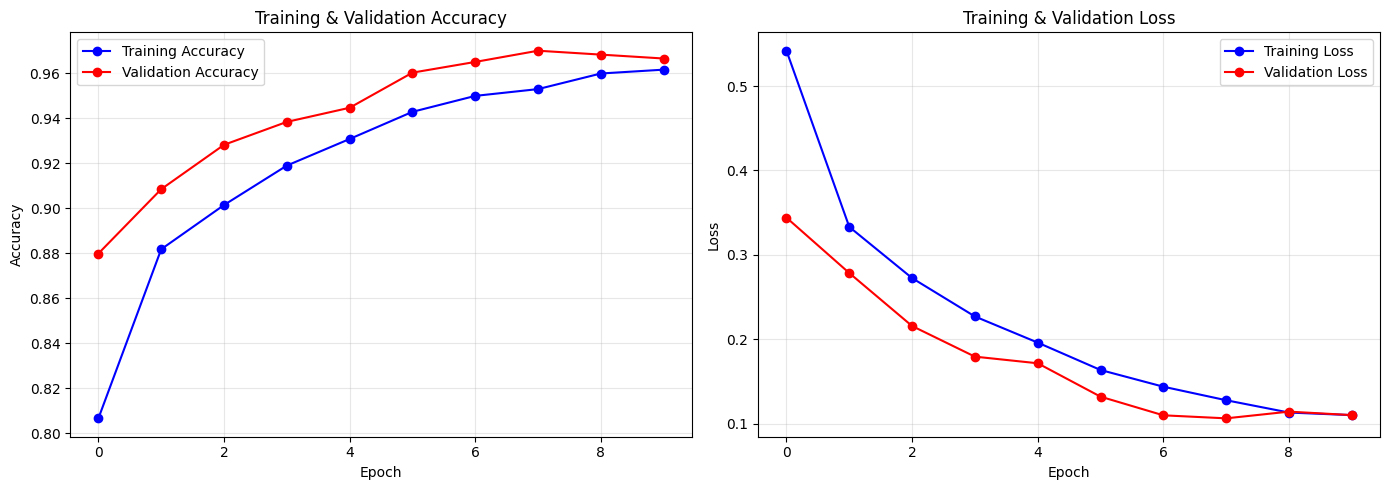

In [15]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, acc, 'b-o', label='Training Accuracy')
ax1.plot(epochs_range, val_acc, 'r-o', label='Validation Accuracy')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, loss, 'b-o', label='Training Loss')
ax2.plot(epochs_range, val_loss, 'r-o', label='Validation Loss')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 13 — Evaluate on Test Set

In [16]:
print('\U0001f4c2 Loading test data...')
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(OUTPUT_ROOT, 'test'),
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
)

print('\n\U0001f50d Evaluating model on test set...')
test_loss, test_acc = model.evaluate(test_ds)
print(f'\n   \U0001f4c8 Test Accuracy : {test_acc * 100:.2f}%')
print(f'   \U0001f4c9 Test Loss     : {test_loss:.4f}')

# Per-class accuracy
print('\n   Per-class breakdown:')
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

for i, cls in enumerate(class_names):
    mask = y_true == i
    if mask.sum() > 0:
        cls_acc = (y_pred[mask] == i).mean() * 100
        label = BIN_LABELS.get(cls, cls)
        print(f'     {label:30s}  {cls_acc:6.2f}%  ({mask.sum()} samples)')

📂 Loading test data...
Found 4616 files belonging to 5 classes.

🔍 Evaluating model on test set...
145/145 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9710 - loss: 0.0964

   📈 Test Accuracy : 97.10%
   📉 Test Loss     : 0.0964

   Per-class breakdown:
     🟦 Glass                          97.83%  (876 samples)
     🟥 Metal                          97.93%  (724 samples)
     🟫 Paper                          99.11%  (1678 samples)
     🟩 Plastic                        95.76%  (826 samples)
     ⬛ Rejected Waste                 90.23%  (512 samples)


## Step 14 — Export Model in Multiple Formats

Exports the trained model in 4 formats:
- **`.keras`** — Native Keras format
- **`.h5`** — Legacy Keras/HDF5 format
- **SavedModel** — TF Serving directory
- **`.tflite`** — TensorFlow Lite for edge/mobile/ESP32 (quantized)

In [17]:
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Keras format (.keras)
keras_path = os.path.join(EXPORT_DIR, f'{MODEL_NAME}.keras')
model.save(keras_path)
print(f'\u2705 Keras  (.keras)     : {keras_path}')

# 2. H5 format (.h5)
h5_path = os.path.join(EXPORT_DIR, f'{MODEL_NAME}.h5')
model.save(h5_path)
print(f'\u2705 H5     (.h5)        : {h5_path}')

# 3. SavedModel format (directory)
savedmodel_path = os.path.join(EXPORT_DIR, f'{MODEL_NAME}_savedmodel')
model.export(savedmodel_path)
print(f'\u2705 SavedModel (dir)    : {savedmodel_path}')

# 4. TFLite format (.tflite)
tflite_path = os.path.join(EXPORT_DIR, f'{MODEL_NAME}.tflite')
try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    tflite_size_mb = os.path.getsize(tflite_path) / (1024 * 1024)
    print(f'\u2705 TFLite (.tflite)    : {tflite_path}  ({tflite_size_mb:.1f} MB)')
except Exception as e:
    print(f'\u26a0\ufe0f  TFLite export failed: {e}')

# 5. Save class names mapping
class_map_path = os.path.join(EXPORT_DIR, 'class_names.txt')
with open(class_map_path, 'w') as f:
    for i, name in enumerate(class_names):
        f.write(f'{i}: {name}\n')
print(f'\u2705 Class map (.txt)    : {class_map_path}')

# Also copy .keras to project root for app.py
root_model_path = 'smart_bin_model.keras'
shutil.copy2(keras_path, root_model_path)
print(f'\n\U0001f4cb Also copied .keras to project root: {root_model_path}')

# Print all exported files with sizes
print(f'\n\U0001f4c1 All exports in: {os.path.abspath(EXPORT_DIR)}')
print('-' * 55)
for fname in sorted(os.listdir(EXPORT_DIR)):
    fpath = os.path.join(EXPORT_DIR, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  \U0001f4c4 {fname:40s}  {size_mb:8.2f} MB')
    elif os.path.isdir(fpath):
        dir_size = sum(os.path.getsize(os.path.join(dp, f))
                       for dp, _, fnames in os.walk(fpath) for f in fnames)
        size_mb = dir_size / (1024 * 1024)
        print(f'  \U0001f4c1 {fname + "/":40s}  {size_mb:8.2f} MB')

✅ Keras  (.keras)     : ./exported_models/smart_bin_model.keras
✅ H5     (.h5)        : ./exported_models/smart_bin_model.h5
Saved artifact at './exported_models/smart_bin_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135156441911120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441911504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441913808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441913424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441912848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441911312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441914000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135156441914768: TensorSpec(shape=(), dtype=tf.resource, name=None)

## Step 15 — Save Training Plot

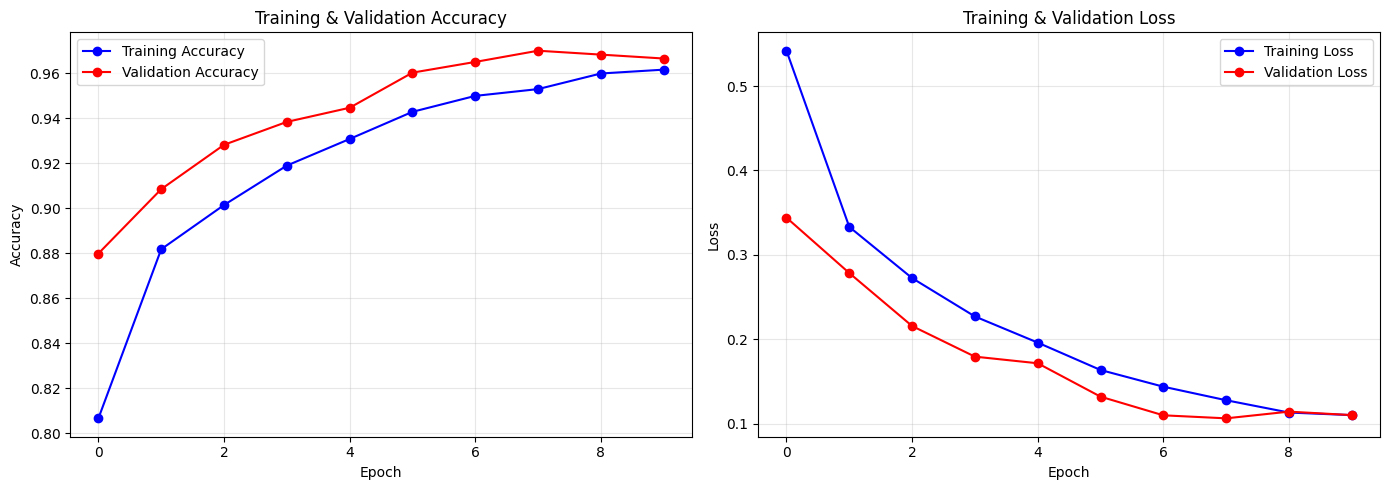

📊 Plot saved to: ./exported_models/training_history.png


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(EPOCHS), acc, 'b-o', label='Training Accuracy')
ax1.plot(range(EPOCHS), val_acc, 'r-o', label='Validation Accuracy')
ax1.set_title('Training & Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(range(EPOCHS), loss, 'b-o', label='Training Loss')
ax2.plot(range(EPOCHS), val_loss, 'r-o', label='Validation Loss')
ax2.set_title('Training & Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(EXPORT_DIR, 'training_history.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f'\U0001f4ca Plot saved to: {plot_path}')

## Step 16 — Download Models (Google Colab)

Run this cell to **copy models to Google Drive** or **download directly** from Colab.

If running locally, your models are already in `./exported_models/`.

In [19]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('\U0001f4e4 Running on Google Colab \u2014 setting up downloads...\n')

    # Option 1: Copy to Google Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)

        drive_dest = '/content/drive/MyDrive/SmartBin_Models'
        os.makedirs(drive_dest, exist_ok=True)

        for item in os.listdir(EXPORT_DIR):
            src = os.path.join(EXPORT_DIR, item)
            dst = os.path.join(drive_dest, item)
            if os.path.isdir(src):
                if os.path.exists(dst):
                    shutil.rmtree(dst)
                shutil.copytree(src, dst)
            else:
                shutil.copy2(src, dst)

        print(f'\u2705 All models copied to Google Drive:')
        print(f'   \U0001f4c1 {drive_dest}\n')
    except Exception as e:
        print(f'\u26a0\ufe0f  Could not copy to Drive: {e}\n')

    # Option 2: Direct browser download
    print('\U0001f4e5 To download files directly to your computer, run:')
    print(f"   from google.colab import files")
    print(f"   files.download('{os.path.join(EXPORT_DIR, MODEL_NAME + '.keras')}')")
    print(f"   files.download('{os.path.join(EXPORT_DIR, MODEL_NAME + '.tflite')}')")
    print(f"   files.download('{os.path.join(EXPORT_DIR, MODEL_NAME + '.h5')}')")
    print(f"   files.download('{os.path.join(EXPORT_DIR, 'class_names.txt')}')")
else:
    print('\U0001f4bb Running locally \u2014 your exported models are in:')
    print(f'   {os.path.abspath(EXPORT_DIR)}')

📤 Running on Google Colab — setting up downloads...

Mounted at /content/drive
✅ All models copied to Google Drive:
   📁 /content/drive/MyDrive/SmartBin_Models

📥 To download files directly to your computer, run:
   from google.colab import files
   files.download('./exported_models/smart_bin_model.keras')
   files.download('./exported_models/smart_bin_model.tflite')
   files.download('./exported_models/smart_bin_model.h5')
   files.download('./exported_models/class_names.txt')


## Step 17 — Final Summary

In [20]:
print('=' * 70)
print('  \u2705 ALL DONE!')
print('=' * 70)
print(f'''
  \U0001f4ca Training Results:
     \u2022 Final Training Accuracy   : {acc[-1]*100:.2f}%
     \u2022 Final Validation Accuracy : {val_acc[-1]*100:.2f}%
     \u2022 Test Accuracy             : {test_acc*100:.2f}%

  \U0001f3f7\ufe0f  Classes: {class_names}

  \U0001f4c1 Exported Models:
     \u2022 {EXPORT_DIR}/{MODEL_NAME}.keras      (Keras native)
     \u2022 {EXPORT_DIR}/{MODEL_NAME}.h5         (Legacy H5)
     \u2022 {EXPORT_DIR}/{MODEL_NAME}.tflite     (TFLite / Edge)
     \u2022 {EXPORT_DIR}/{MODEL_NAME}_savedmodel (TF SavedModel)

  \U0001f504 To use with the Flask API:
     The model has been copied to 'smart_bin_model.keras'
     Just restart app.py and it will load the new 5-class model.
''')
print('=' * 70)

  ✅ ALL DONE!

  📊 Training Results:
     • Final Training Accuracy   : 96.16%
     • Final Validation Accuracy : 96.66%
     • Test Accuracy             : 97.10%

  🏷️  Classes: ['glass', 'metal', 'paper', 'plastic', 'rejected_waste']

  📁 Exported Models:
     • ./exported_models/smart_bin_model.keras      (Keras native)
     • ./exported_models/smart_bin_model.h5         (Legacy H5)
     • ./exported_models/smart_bin_model.tflite     (TFLite / Edge)
     • ./exported_models/smart_bin_model_savedmodel (TF SavedModel)

  🔄 To use with the Flask API:
     The model has been copied to 'smart_bin_model.keras'
     Just restart app.py and it will load the new 5-class model.



---
## 📝 Notes

**5-Bin compartment logic:**
```
BIN 1  glass           →  glass, green-glass, brown-glass, white-glass (DS1) + glass (DS2)
BIN 2  metal           →  metal (both datasets)
BIN 3  paper           →  paper, cardboard (both datasets)
BIN 4  plastic         →  plastic (both datasets)
BIN 5  rejected_waste  →  biological, clothes, shoes, battery, trash (DS1) + trash (DS2)
```

**File naming:** Each image is prefixed with its source dataset and original category  
(e.g. `ds1__glass__img001.jpg`, `ds2__Glass__img042.jpg`)

**Dataset 2 auto-split:** Since Dataset 2 has no train/val/test splits, images are randomly  
shuffled and split 70/15/15 with seed=42 for reproducibility.

**Training tip:** With class imbalance likely in `rejected_waste` (many merged categories),  
consider using `class_weight='balanced'` or data augmentation if accuracy is low.

📷 Upload an image to classify it...



Saving Screenshot 2026-06-24 160234.png to Screenshot 2026-06-24 160234.png

🔍 Classifying: Screenshot 2026-06-24 160234.png
--------------------------------------------------


/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 129003 (\N{LARGE BROWN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 129001 (\N{LARGE GREEN SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1651/1009441163.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/l

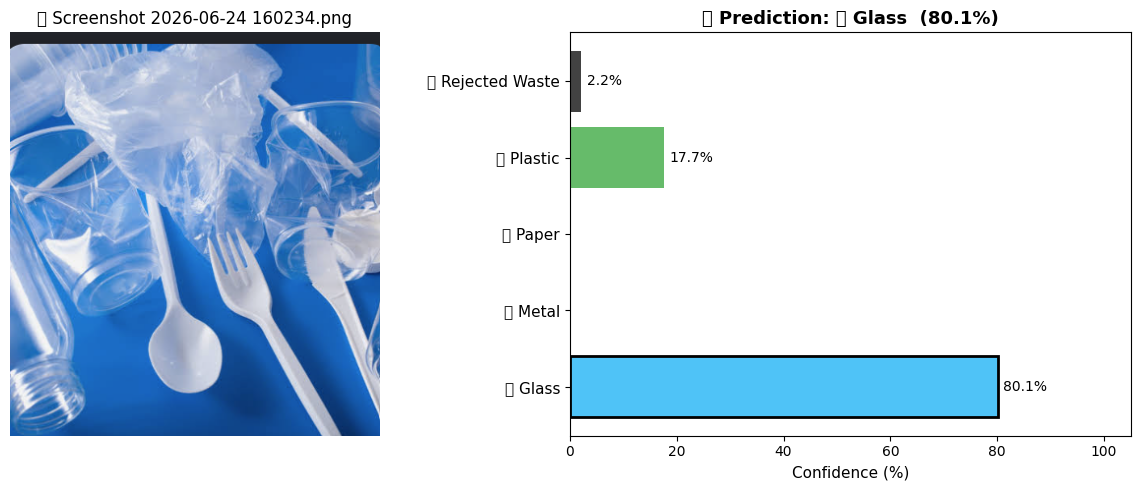


🏷️  Result: This item should go in the 🟦 Glass bin
   Confidence: 80.14%


In [31]:
from tensorflow.keras.preprocessing import image as keras_image
from PIL import Image
import io

# --- Emoji labels for display ---
BIN_EMOJI = {
    'glass':          '\U0001f7e6 Glass',
    'metal':          '\U0001f7e5 Metal',
    'paper':          '\U0001f7eb Paper',
    'plastic':        '\U0001f7e9 Plastic',
    'rejected_waste': '\u2b1b Rejected Waste',
}

def predict_and_show(img_path_or_bytes, filename='uploaded_image'):
    """Run prediction on an image and display results."""
    # Load image
    if isinstance(img_path_or_bytes, (bytes, bytearray)):
        img = Image.open(io.BytesIO(img_path_or_bytes)).convert('RGB')
    else:
        img = Image.open(img_path_or_bytes).convert('RGB')

    img_resized = img.resize(IMG_SIZE)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)
    scores = predictions[0]

    predicted_idx = np.argmax(scores)
    predicted_class = class_names[predicted_idx]
    confidence = float(scores[predicted_idx] * 100)

    # Display image with prediction
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1.2]})

    # Show image
    ax1.imshow(img)
    ax1.set_title(f'\U0001f4f7 {filename}', fontsize=12)
    ax1.axis('off')

    # Show prediction bars
    colors = ['#4FC3F7', '#EF5350', '#8D6E63', '#66BB6A', '#424242']
    bars = ax2.barh(range(len(class_names)), scores * 100, color=colors)
    ax2.set_yticks(range(len(class_names)))
    ax2.set_yticklabels([BIN_EMOJI.get(c, c) for c in class_names], fontsize=11)
    ax2.set_xlabel('Confidence (%)', fontsize=11)
    ax2.set_xlim(0, 105)
    ax2.set_title(f'\u2705 Prediction: {BIN_EMOJI.get(predicted_class, predicted_class)}  ({confidence:.1f}%)',
                  fontsize=13, fontweight='bold')

    # Add % labels on bars
    for bar, score in zip(bars, scores):
        if score > 0.01:
            ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{score*100:.1f}%', va='center', fontsize=10)

    # Highlight the predicted bar
    bars[predicted_idx].set_edgecolor('black')
    bars[predicted_idx].set_linewidth(2)

    plt.tight_layout()
    plt.show()

    print(f'\n\U0001f3f7\ufe0f  Result: This item should go in the {BIN_EMOJI.get(predicted_class, predicted_class)} bin')
    print(f'   Confidence: {confidence:.2f}%')
    return predicted_class, confidence


# --- Upload and test ---
try:
    # Google Colab: use file upload dialog
    from google.colab import files as colab_files
    print('\U0001f4f7 Upload an image to classify it...\n')
    uploaded = colab_files.upload()

    for filename, data in uploaded.items():
        print(f'\n\U0001f50d Classifying: {filename}')
        print('-' * 50)
        predict_and_show(data, filename)

except ImportError:
    # Jupyter/Local: use ipywidgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output

        upload_widget = widgets.FileUpload(
            accept='image/*',
            multiple=False,
            description='Upload Image'
        )
        output = widgets.Output()

        def on_upload(change):
            if upload_widget.value:
                with output:
                    clear_output()
                    try:
                        if isinstance(upload_widget.value, dict):
                            fname = list(upload_widget.value.keys())[0]
                            content = upload_widget.value[fname]['content']
                        else:
                            uploaded_file = upload_widget.value[0]
                            fname = uploaded_file.get('name', 'uploaded_image')
                            content = uploaded_file['content']

                        print(f'\n\U0001f50d Classifying: {fname}')
                        print('-' * 50)
                        predict_and_show(content, fname)
                    except Exception as e:
                        print(f'\u26a0\ufe0f Error: {e}')

        upload_widget.observe(on_upload, names='value')
        print('\U0001f4f7 Click the button below to upload an image:')
        display(upload_widget)
        display(output)

    except ImportError:
        # Fallback: manual file path
        print('\U0001f4f7 Enter the path to an image file to classify it:')
        img_path = input('Image path: ').strip()
        if img_path and os.path.exists(img_path):
            predict_and_show(img_path, os.path.basename(img_path))
        else:
            print('\u26a0\ufe0f File not found.')